# Pregunta de negocio 01/06/2026

**Analista de Perfil i Desempeño Professional:**  
- Quines característiques dels empleats estan associades amb un millor acompliment laboral
- com podem utilitzar aquesta informació per dissenyar estratègies de selecció, capacitació i retenció més efectives?

# Librerías

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np
import plotly.graph_objs as go

# Documento

In [2]:
df_RRHH = pd.read_csv('../../Data/raw/raw_data_01062026.csv')
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


# Conteo registros

In [3]:
def control_registros(df):

    fecha_actual = date.today()

    total_registros = df.shape[0]
    ID_unicos = df['ID'].nunique()
    ID_extra = total_registros - ID_unicos
    ID_duplicados_exactos = df[df.duplicated(keep=False)].drop_duplicates().shape[0]


    print('--------------------\nCONTROL DE REGISTROS\n--------------------')
    print(f'Fecha: {fecha_actual}\n--------------------')
    print(f'TOTAL REGISTROS: {total_registros}')
    print(f'ID ÚNICOS: {ID_unicos}')
    print(f'ID EXTRAS: {ID_extra}')
    print(f'ID DUPLICADOS EXACTOS: {ID_duplicados_exactos}')

In [4]:
control_registros(df_RRHH) 


--------------------
CONTROL DE REGISTROS
--------------------
Fecha: 2026-06-03
--------------------
TOTAL REGISTROS: 845
ID ÚNICOS: 136
ID EXTRAS: 709
ID DUPLICADOS EXACTOS: 31


# Pregunta de negocio

In [5]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='str')

In [6]:
df_RRHH.shape

(845, 21)

In [7]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,845.0,26.128994,26.374062,1.0,10.0,20.0,33.0,136.0
Reason_absence,845.0,19.280473,8.296957,0.0,13.0,23.0,26.0,28.0
Month_absence,845.0,6.315976,3.457020,0.0,3.0,6.0,9.0,12.0
Day_week,845.0,3.926627,1.417331,2.0,3.0,4.0,5.0,6.0
Seasons,845.0,2.540828,1.111040,1.0,2.0,3.0,4.0,4.0
Transportation_expense,845.0,220.482840,67.416501,118.0,179.0,225.0,260.0,388.0
Distance_Residence_Work,845.0,29.418935,14.740235,5.0,16.0,26.0,49.0,52.0
Service_time,845.0,12.578698,4.424460,1.0,9.0,12.0,16.0,29.0
Age,845.0,36.443787,6.555322,27.0,31.0,37.0,40.0,58.0
Hit_target,845.0,94.572781,3.798349,81.0,93.0,95.0,97.0,100.0


## Distribución variable hit target (histograma y boxplot [outlier])

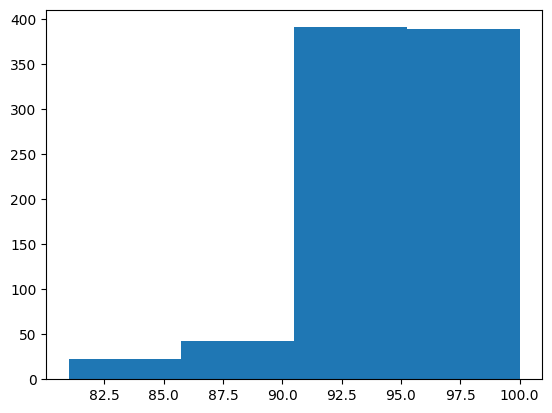

In [14]:
plt.hist(df_RRHH['Hit_target'], bins=4)
plt.show()

In [26]:
df_RRHH['Hit_target'].value_counts(normalize=True)*100

Hit_target
93     14.674556
99     14.082840
97     11.834320
92     10.532544
96      9.940828
95      9.940828
98      8.757396
91      6.508876
94      4.615385
88      3.431953
81      2.721893
87      1.538462
100     1.420118
Name: proportion, dtype: float64

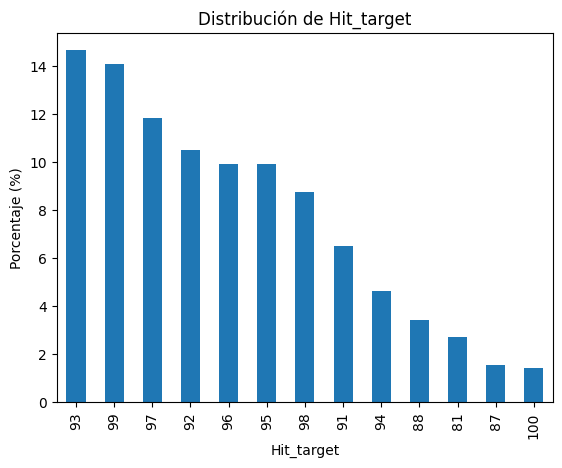

In [27]:
(df_RRHH['Hit_target']
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind='bar'))

plt.ylabel('Porcentaje (%)')
plt.xlabel('Hit_target')
plt.title('Distribución de Hit_target')
plt.show()

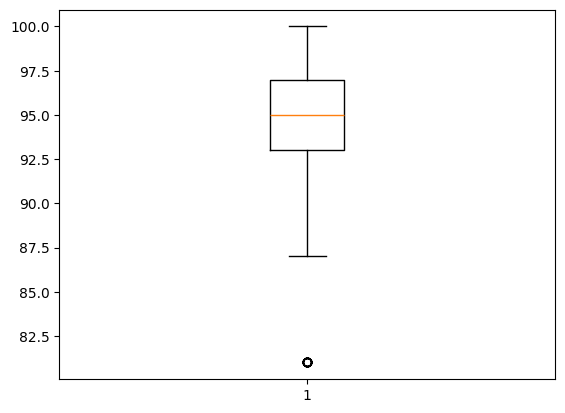

In [9]:
plt.boxplot(df_RRHH['Hit_target'])
plt.show()

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
El valor **outlier es 81** (hay 23 registros), que es el mínimo, el siguiente valor es 88.

In [ ]:
col = df_RRHH['Hit_target']

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

limit_inferior = Q1 - 1.5 * IQR
limit_superior = Q3 + 1.5 * IQR

outliers = df_RRHH[(col < limit_inferior) | (col > limit_superior)]

,Hit_target
20,81
25,81
36,81
52,81
148,81
149,81
150,81
151,81
301,81
302,81


In [20]:
outliers

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
20,15,7,9,2,4,291,31,12,40,"294,217",...,0,1,1,1,0,1,73,171,25,40
25,24,9,9,4,1,246,25,16,41,"294,217",...,0,1,0,1,0,0,67,170,23,32
36,11,19,9,4,1,289,36,13,33,"294,217",...,0,1,2,1,0,1,90,172,30,24
52,24,9,9,2,1,246,25,16,41,"294,217",...,0,1,0,1,0,0,67,170,23,16
148,3,11,9,2,1,179,51,18,38,"294,217",...,0,1,0,1,0,0,89,170,31,8
149,3,13,9,4,1,179,51,18,38,"294,217",...,0,1,0,1,0,0,89,170,31,8
150,5,26,9,4,4,235,20,13,43,"294,217",...,0,1,1,1,0,0,106,167,38,8
151,3,13,9,2,4,179,51,18,38,"294,217",...,0,1,0,1,0,0,89,170,31,8
301,15,28,9,6,1,291,31,12,40,"294,217",...,0,1,1,1,0,1,73,171,25,4
302,20,28,9,6,1,260,50,11,36,"294,217",...,0,1,4,1,0,0,65,168,23,4


In [23]:
df_RRHH['Hit_target'].unique()

array([ 97,  98,  93,  92,  99,  94,  88,  96,  95,  81, 100,  91,  87])

### Por cada uno de los grupos

## Tamaño de muestra

In [10]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       845 non-null    int64
 1   Reason_absence           845 non-null    int64
 2   Month_absence            845 non-null    int64
 3   Day_week                 845 non-null    int64
 4   Seasons                  845 non-null    int64
 5   Transportation_expense   845 non-null    int64
 6   Distance_Residence_Work  845 non-null    int64
 7   Service_time             845 non-null    int64
 8   Age                      845 non-null    int64
 9   Work_load_Average_day    845 non-null    str  
 10  Hit_target               845 non-null    int64
 11  Disciplinary_failure     845 non-null    int64
 12  Education                845 non-null    int64
 13  Son                      845 non-null    int64
 14  Social_drinker           845 non-null    int64
 15  Social_smoker    

In [11]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [12]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Disciplinary_failure
0    135
1      1
Name: count, dtype: int64
Disciplinary_failure
0    99.264706
1     0.735294
Name: proportion, dtype: float64
Education
1    114
3     12
2      9
4      1
Name: count, dtype: int64
Education
1    83.823529
3     8.823529
2     6.617647
4     0.735294
Name: proportion, dtype: float64
Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64
Son
0    43.382353
1    30.147059
2    20.588235
3     3.676471
4     2.205882
Name: proportion, dtype: float64
Social_drinker
1    71
0    65
Name: count, dtype: int64
Social_drinker
1    52.205882
0    47.794118
Name: proportion, dtype: float64
Social_smoker
0    122
1     14
Name: count, dtype: int64
Social_smoker
0    89.705882
1    10.294118
Name: proportion, dtype: float64
Pet
0    83
1    24
2    21
4     5
8     2
5     1
Name: count, dtype: int64
Pet
0    61.029412
1    17.647059
2    15.441176
4     3.676471
8     1.470588
5     0.735294
Name: proportion, dtype: float64
